## Part 0: Set up

This notebook demonstrates the IPCA (Instrumented Principal Components Analysis) model
from Kelly, Pruitt, and Su (2019). Please make sure you have installed **scipy**, **scikit-learn**,
**numpy**, and **pandas**. The following command will install all required packages.

In [2]:
# Import core libraries for numerical computation, data handling, and linear algebra.
# - numpy/pandas: array and dataframe operations
# - svds: sparse SVD, used in IPCA initialization
# - linear_model: OLS regression used in IPCA factor/Gamma estimation
# Suppress FutureWarnings from sklearn/pandas for cleaner output.
import warnings
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import time as tm
from scipy.sparse.linalg import svds
from sklearn import linear_model
warnings.simplefilter(action="ignore", category=FutureWarning)

In [3]:
# Load simulated data for one replicate (an=1) of DGP variant M=1.
# Two data files are loaded:
#   c_1.csv:  (N*T, P) panel of asset characteristics z_{i,t}. Each row is one
#             asset-time observation; columns are the P=50 characteristics.
#   r1_1.csv: (N*T,) vector of simulated individual stock returns, stacked as
#             [r_{1,1},...,r_{N,1}, r_{1,2},...,r_{N,2}, ..., r_{1,T},...,r_{N,T}].
M, an = 1, 1
P = 50
path = "demo_data"
data = pd.read_csv(path + "/c_%d.csv" % an, delimiter=",").values
r = pd.read_csv(path + "/r%d_%d.csv" % (M, an), delimiter=",").values[:, 0]

In [4]:
# Define panel dimensions and create panel identifiers.
#   N = 200 assets, T = 180 time periods, K = 5 latent factors, P = 50 characteristics.
# `per`:  asset (entity) identifier for each of the N*T stacked observations.
#         Repeats [0,1,...,N-1] for each time period.
# `time`: time period identifier for each observation.
#         Repeats each period index N times (one per asset).
# `date`: alias for `time`, used interchangeably throughout the code.
N = 200  ### Number of CS tickers
m = P    ### Number of Characteristics
T = 180  ### Number of Time Periods
K = 5    ### Number of principal components

per = np.tile(np.arange(N), T)
time = np.repeat(np.arange(T), N)
date = time

In [5]:
date

array([  0,   0,   0, ..., 179, 179, 179], shape=(36000,))

In [6]:
# Split data into three equal time-based folds (each covering T/3 = 60 periods):
#   1. Training set   (periods 0-59):    used to fit model parameters.
#   2. Validation set  (periods 60-119):  used for early stopping / hyperparameter tuning.
#   3. Out-of-sample   (periods 120-179): used to evaluate final predictive performance.
#
# For each split, we extract:
#   - Characteristics matrix (xtrain/xtest/xoos): input to the beta network
#   - Returns vector (ytrain/ytest/yoos): target variable
#   - Entity identifiers (trainper/testper/oosper) and time identifiers (traindate/testdate/oosdate)
ind = range(0, int(N * T / 3))
xtrain = data[ind, :]
ytrain = r[ind]
trainper = per[ind]
traindate = time[ind]

ind = range(int(N * T / 3), int(N * (T * 2 / 3)))
xtest = data[ind, :]
ytest = r[ind]
testper = per[ind]
testdate = time[ind]

ind = range(int(N * T * 2 / 3), N * T)
xoos = data[ind, :]
yoos = r[ind]
oosdate = time[ind]
oosper = per[ind]

In [7]:
# Precompute summary statistics needed by IPCA.
#
# Nt[t]:    Number of assets at time t (here always N=200, balanced panel).
#
# X (P x T): Cross-sectional "managed portfolio" moments. Column t is:
#     X[:, t] = (1/N_t) * Z_t' * r_t
#   i.e., the characteristics-weighted average return at time t.
#   This is the sufficient statistic for estimating factors in IPCA.
#
# W (P x P x T): Cross-sectional second moment of characteristics at time t:
#     W[:, :, t] = (1/N_t) * Z_t' * Z_t
#   Used by IPCA in the ALS (alternating least squares) estimation step.
L = P
udate = np.unique(time)
Nt = np.zeros(T)
for i in range(T):
    ind = time == udate[i]
    Nt[i] = np.sum(ind)
Nt = Nt.astype(int)

X = np.zeros((L, T))
for t in range(T):
    ind = time == udate[t]
    xt = r[ind].reshape(1, Nt[t]).dot(data[ind, :])
    X[:, t] = xt[0, :] / 1.0 / Nt[t]

W = np.zeros((L, L, T))
for t in range(T):
    ind = time == udate[t]
    Z = data[ind, :]
    W[:, :, t] = Z.T.dot(Z) / Nt[t]

## Part 1: Introduction

**Kelly, Pruitt, and Su (KPS, 2019)**

A recent asset pricing literature has emerged challenging the "anomaly" view of characteristic-based asset return prediction. The anomaly view suggests that certain asset attributes have the power to forecast returns above and beyond the expected return variation warranted as compensation for aggregate risk exposures. [Kelly, Pruitt, and Su (KPS, 2019)](https://www.nber.org/system/files/working_papers/w24540/w24540.pdf) provide empirical evidence that these so-called anomaly asset characteristics in fact proxy for unobservable and time-varying exposures to risk factors, and shows that characteristics contain little (if any) anomalous return predictability once their explanatory power for factor exposures has been accounted for. In other words, characteristics appear to predict returns because they help pinpoint compensated aggregate risk exposures.

The asset pricing model proposed by [KPS](https://www.nber.org/system/files/working_papers/w24540/w24540.pdf) assumes that individual returns $r_{i, t}$ possess a $K$-factor structure:
$$
r_{i, t}=\beta\left(z_{i, t-1}\right)^{\prime} f_{t}+u_{i, t}  \tag{1}
$$
The factors $f_{t}$ are treated as latent, and the $K \times 1$ conditional factor exposure $\beta\left(z_{i, t-1}\right)$ is a function of an $P \times 1$ vector of asset characteristics $z_{i, t-1}$, where $P$ is potentially high dimensional and strictly greater than $K$. [KPS](https://www.nber.org/system/files/working_papers/w24540/w24540.pdf) make the simplifying assumption that the map from $P$ characteristics to $K$ betas is linear:
$$
\beta\left(z_{i, t-1}\right)^{\prime}=z_{i, t-1}^{\prime} \Gamma  \tag{2}
$$
which leads to an especially tractable estimation strategy for both the beta function and the latent factors.

There are, nonetheless, no obvious theoretical or intuitive justifications for this convenient linearity assumption. To the contrary, there are many reasons to expect that this assumption is violated. Essentially all leading theoretical asset pricing models predict nonlinearities in return dynamics as a function of state variables; [Campbell and Cochrane (1999)](https://www.jstor.org/stable/10.1086/250059?seq=1), [Bansal and Yaron (2004)](https://www.jstor.org/stable/3694869?seq=1), and [He and Krishnamurthy (2013)](https://www.aeaweb.org/articles?id=10.1257/aer.103.2.732) are prominent examples. Theory also predicts complex dynamics in factor risk exposures, as shown for example in the general equilibrium model of [Santos and Veronesi (2004)](https://www.nber.org/papers/w10413). Moreover, [Pohl et al. (2018)](https://onlinelibrary.wiley.com/doi/abs/10.1111/jofi.12615) show that linear approximations to nonlinear models can lead to considerable errors in the model predictions for the magnitude of the equity premium or return predictability.

## Part 2: IPCA

Just like the autoencoder model nests the static linear factor model, the augmented autoencoder nests the IPCA factor model proposed by [KPS](https://www.nber.org/system/files/working_papers/w24540/w24540.pdf) as a special case. [KPS](https://www.nber.org/system/files/working_papers/w24540/w24540.pdf) propose a method called IPCA to estimate their linear, time-varying beta model. IPCA solves the optimization problem:
$$
\min _{\Gamma, F} \sum_{t=1}^{T} \sum_{i=1}^{N}\left\|r_{i, t}-z_{i, t-1}^{\prime} \Gamma^{\prime} f_{t}\right\|^{2}=\min _{\Gamma, F} \sum_{t=1}^{T}\left\|r_{t}-Z_{t-1} \Gamma^{\prime} f_{t}\right\|^{2}  \tag{17}
$$
where $F=\left(f_{1}, f_{2}, \ldots, f_{T}\right)$ and $Z_{t}=\left(z_{1, t}^{\prime}, z_{2, t}^{\prime}, \ldots, z_{N, t}^{\prime}\right)^{\prime}$, and subject to restrictions that identify a unique rotation of factors.

For comparison, consider a particularly simple version of the conditional autoencoder that uses a linear activation function and one layer of $K$ neurons on both the beta side and the factor side of the network. In this case, $\beta_{i, t}^{\prime}=Z_{t-1} W_{0}^{\prime}$ and $f_{t}=W_{1} x_{t}$, so the the estimation objective of the conditional autoencoder is:
$$
\min _{W_{0}, W_{1}} \sum_{t=1}^{T}\left\|r_{t}-Z_{t-1} W_{0}^{\prime} W_{1} x_{t}\right\|^{2}  \tag{18}
$$
The next proposition formalizes the equivalence between IPCA and this linear conditional autoencoder.

**Proposition 2.** The solution to (18) is equivalent to the solution of (17) if $Z_{t}^{\prime} Z_{t}=\Sigma$ for a constant $\operatorname{matrix} \Sigma$.

In the general case where $Z_{t}^{\prime} Z_{t}$ is non-constant, the two estimators are similar but no longer equivalent (as we can see from the proof). We find that the empirical performance of (17) and (18) is similar in our data.

In [8]:
# ---- Part 2: Train the IPCA Model (Kelly, Pruitt, Su 2019) ----
from IPCA import IPCA
start_time_ipca = tm.time()
ret_hat_ipca, ret_hatp_ipca, Gamma_ipca = IPCA(X, W, Nt, time, udate)
end_time_ipca = tm.time()
time_ipca = end_time_ipca - start_time_ipca

In [9]:
r2_ipca = np.zeros(2)
ind = range(int(N * T * 2 / 3), N * T)
r2_ipca[0] = 1 - np.mean(np.power(ret_hat_ipca[ind] - yoos, 2)) / np.mean(np.power(yoos, 2))
r2_ipca[1] = 1 - np.mean(np.power(ret_hatp_ipca[ind] - yoos, 2)) / np.mean(np.power(yoos, 2))
print(f"IPCA Total R^2: {r2_ipca[0]:.4f}")
print(f"IPCA Predictive R^2: {r2_ipca[1]:.4f}")
print(f"IPCA Execution Time: {time_ipca:.2f} seconds")

IPCA Total R^2: 0.4443
IPCA Predictive R^2: 0.0372
IPCA Execution Time: 2.72 seconds


## Part 3: Regressed-PCA

### Regressed-Principal Components Analysis (RPCA)

**Overview:** RPCA is a computationally efficient, non-iterative alternative to iterative methods like IPCA. It compresses cross-sectional asset characteristics into managed portfolios and extracts common latent factors using standard PCA.

**Core Methodology:**

1. **Form Managed Portfolios:** Compute cross-sectional characteristic-weighted returns ($X_t$) for each period: $$X_t = \frac{1}{N_t} Z_t^\top r_t$$

2. **Run PCA:** Perform PCA on the $P \times T$ matrix $X$ to find the top $K$ characteristic loadings ($\Gamma$) and time factors ($F$):
   $$\min_{\Gamma, F} \sum_{t=1}^T \|X_t - \Gamma f_t\|_2^2 \quad \text{s.t.} \quad \frac{1}{T} F F^\top = I_K$$

3. **Extract Factors:** $\Gamma$ is obtained via the top $K$ eigenvectors of the sample covariance of $X$. The factor scores are computed as: $$f_t = \Gamma^\top X_t$$

4. **Reconstruct Returns:** Estimate time-varying asset betas ($\beta_{i,t} = z_{i,t}^\top \Gamma$) to predict individual stock returns: $$\hat{r}_{i,t} = z_{i,t}^\top \Gamma f_t$$

Relying on a single SVD/PCA makes RPCA substantially faster and more stable than Alternating Least Squares (ALS).
* **Reference:** Chen, Roussanov, and Wang (2025).

In [10]:
from RPCA import RegressedPCA

In [11]:
#ret_hat = returns using f_t at all time periods
#ret_hatp = returns using expanding-window mean of f_t for out-of-sample periods

start_time_rpca = tm.time()
ret_hat_rpca, ret_hatp_rpca, Gamma_rpca = RegressedPCA(X, W, Nt, time, udate)
end_time_rpca = tm.time()
time_rpca = end_time_rpca - start_time_rpca

In [12]:
r2_rpca = np.zeros(2)
ind = range(int(N * T * 2 / 3), N * T)
r2_rpca[0] = 1 - np.mean(np.power(ret_hat_rpca[ind] - yoos, 2)) / np.mean(np.power(yoos, 2))
r2_rpca[1] = 1 - np.mean(np.power(ret_hatp_rpca[ind] - yoos, 2)) / np.mean(np.power(yoos, 2))
print(f"RPCA Total R^2: {r2_rpca[0]:.4f}")
print(f"RPCA Predictive R^2: {r2_rpca[1]:.4f}")
print(f"RPCA Execution Time: {time_rpca:.2f} seconds")

RPCA Total R^2: 0.4431
RPCA Predictive R^2: 0.0375
RPCA Execution Time: 0.11 seconds


## Part 4: Comparison single run

We compare the performance of IPCA and Regressed-PCA based on three key metrics from a single Monte Carlo simulation run:

1.  **Total R²**: Measures the in-sample explanatory power of the model using contemporaneous factors. It shows how well the model fits the data it was trained on.

2.  **Predictive R²**: Measures the out-of-sample predictive power. It evaluates how well the model forecasts returns on unseen data, using a predictive factor estimate (the expanding window mean of past factors).

3.  **Execution Time**: The wall-clock time required to estimate the model.


The results show that both models achieve very similar explanatory and predictive power, but Regressed-PCA is substantially faster due to its non-iterative estimation procedure.

In [13]:
results = {
    'Metric': ['Total R^2', 'Predictive R^2', 'Execution Time (s)'],
    'IPCA': [r2_ipca[0], r2_ipca[1], time_ipca],
    'Regressed-PCA': [r2_rpca[0], r2_rpca[1], time_rpca]
}

df_results = pd.DataFrame(results).set_index('Metric')
print("Monte Carlo Summary Table")
print(df_results.round(4))

Monte Carlo Summary Table
                      IPCA  Regressed-PCA
Metric                                   
Total R^2           0.4443         0.4431
Predictive R^2      0.0372         0.0375
Execution Time (s)  2.7169         0.1138


## Part 5: Monte Carlo 200 simulations

In [14]:
# Initialize lists to store results from each simulation
num_simulations = 20
ipca_r2_total = []
ipca_r2_pred = []
ipca_times = []
rpca_r2_total = []
rpca_r2_pred = []
rpca_times = []

for m_sim in range(1, num_simulations + 1):
    if m_sim % 10 == 0:
        print(f'Running simulation {m_sim}/{num_simulations}')
    # Load data for the current simulation
    M, an = 1, m_sim
    P = 50 # number of characteristics
    path = "demo_data"
    data = pd.read_csv(path + "/c_%d.csv" % an, delimiter=",").values
    r = pd.read_csv(path + "/r%d_%d.csv" % (M, an), delimiter=",").values[:, 0]

    # The RPCA and IPCA functions use internal global copies of the data.
    # We must explicitly overwrite them with the newly loaded data for this simulation loop.
    import IPCA
    import RPCA
    IPCA.data = data
    IPCA.r = r
    RPCA.data = data
    RPCA.r = r
    # -------------------------------------------------------

    # Define panel dimensions and create panel identifiers.
    N = 200
    m = P
    T = 180
    K = 5

    per = np.tile(np.arange(N), T)
    time = np.repeat(np.arange(T), N)
    date = time

    # Split data into train, validation, and out-of-sample sets
    ind = range(0, int(N * T / 3))
    xtrain = data[ind, :]
    ytrain = r[ind]
    trainper = per[ind]
    traindate = time[ind]

    ind = range(int(N * T / 3), int(N * (T * 2 / 3)))
    xtest = data[ind, :]
    ytest = r[ind]
    testper = per[ind]
    testdate = time[ind]

    ind = range(int(N * T * 2 / 3), N * T)
    xoos = data[ind, :]
    yoos = r[ind]
    oosdate = time[ind]
    oosper = per[ind]

    # Precompute summary statistics
    L = P
    udate = np.unique(time)
    Nt = np.zeros(T)
    for i in range(T):
        ind = time == udate[i]
        Nt[i] = np.sum(ind)
    Nt = Nt.astype(int)

    X = np.zeros((L, T))
    for t in range(T):
        ind = time == udate[t]
        xt = r[ind].reshape(1, Nt[t]).dot(data[ind, :])
        X[:, t] = xt[0, :] / 1.0 / Nt[t]

    W = np.zeros((L, L, T))
    for t in range(T):
        ind = time == udate[t]
        Z = data[ind, :]
        W[:, :, t] = Z.T.dot(Z) / Nt[t]

    # Run IPCA
    start_time_ipca = tm.time()
    ret_hat_ipca, ret_hatp_ipca, Gamma_ipca = IPCA.IPCA(X, W, Nt, time, udate)
    end_time_ipca = tm.time()
    time_ipca = end_time_ipca - start_time_ipca

    r2_ipca = np.zeros(2)
    ind = range(int(N * T * 2 / 3), N * T)
    r2_ipca[0] = 1 - np.mean(np.power(ret_hat_ipca[ind] - yoos, 2)) / np.mean(np.power(yoos, 2))
    r2_ipca[1] = 1 - np.mean(np.power(ret_hatp_ipca[ind] - yoos, 2)) / np.mean(np.power(yoos, 2))
    ipca_r2_total.append(r2_ipca[0])
    ipca_r2_pred.append(r2_ipca[1])
    ipca_times.append(time_ipca)

    # Run RPCA
    start_time_rpca = tm.time()
    ret_hat_rpca, ret_hatp_rpca, Gamma_rpca = RPCA.RegressedPCA(X, W, Nt, time, udate)
    end_time_rpca = tm.time()
    time_rpca = end_time_rpca - start_time_rpca

    r2_rpca = np.zeros(2)
    ind = range(int(N * T * 2 / 3), N * T)
    r2_rpca[0] = 1 - np.mean(np.power(ret_hat_rpca[ind] - yoos, 2)) / np.mean(np.power(yoos, 2))
    r2_rpca[1] = 1 - np.mean(np.power(ret_hatp_rpca[ind] - yoos, 2)) / np.mean(np.power(yoos, 2))
    rpca_r2_total.append(r2_rpca[0])
    rpca_r2_pred.append(r2_rpca[1])
    rpca_times.append(time_rpca)


Running simulation 10/20
Running simulation 20/20


In [15]:
# Calculate average results
avg_ipca_r2_total = np.mean(ipca_r2_total)
avg_ipca_r2_pred = np.mean(ipca_r2_pred)
avg_ipca_time = np.mean(ipca_times)

avg_rpca_r2_total = np.mean(rpca_r2_total)
avg_rpca_r2_pred = np.mean(rpca_r2_pred)
avg_rpca_time = np.mean(rpca_times)

# Calculate standard deviations
std_ipca_r2_total = np.std(ipca_r2_total)
std_ipca_r2_pred = np.std(ipca_r2_pred)
std_ipca_time = np.std(ipca_times)

std_rpca_r2_total = np.std(rpca_r2_total)
std_rpca_r2_pred = np.std(rpca_r2_pred)
std_rpca_time = np.std(rpca_times)

# Create summary table 
results = {
    'Metric': ['Total R^2', 'Predictive R^2', 'Execution Time (s)'],
    'IPCA': [
        f"{avg_ipca_r2_total:.4f} ± {std_ipca_r2_total:.4f}", 
        f"{avg_ipca_r2_pred:.4f} ± {std_ipca_r2_pred:.4f}", 
        f"{avg_ipca_time:.4f} ± {std_ipca_time:.4f}"
    ],
    'Regressed-PCA': [
        f"{avg_rpca_r2_total:.4f} ± {std_rpca_r2_total:.4f}", 
        f"{avg_rpca_r2_pred:.4f} ± {std_rpca_r2_pred:.4f}", 
        f"{avg_rpca_time:.4f} ± {std_rpca_time:.4f}"
    ]
}

df_results = pd.DataFrame(results).set_index('Metric')
print(f"Monte Carlo Summary Table (Averages over {num_simulations} simulations)")
print(df_results)

Monte Carlo Summary Table (Averages over 20 simulations)
                               IPCA    Regressed-PCA
Metric                                              
Total R^2           0.4122 ± 0.0323  0.4111 ± 0.0321
Predictive R^2      0.0301 ± 0.0186  0.0301 ± 0.0186
Execution Time (s)  4.5299 ± 2.9899  0.0633 ± 0.0005


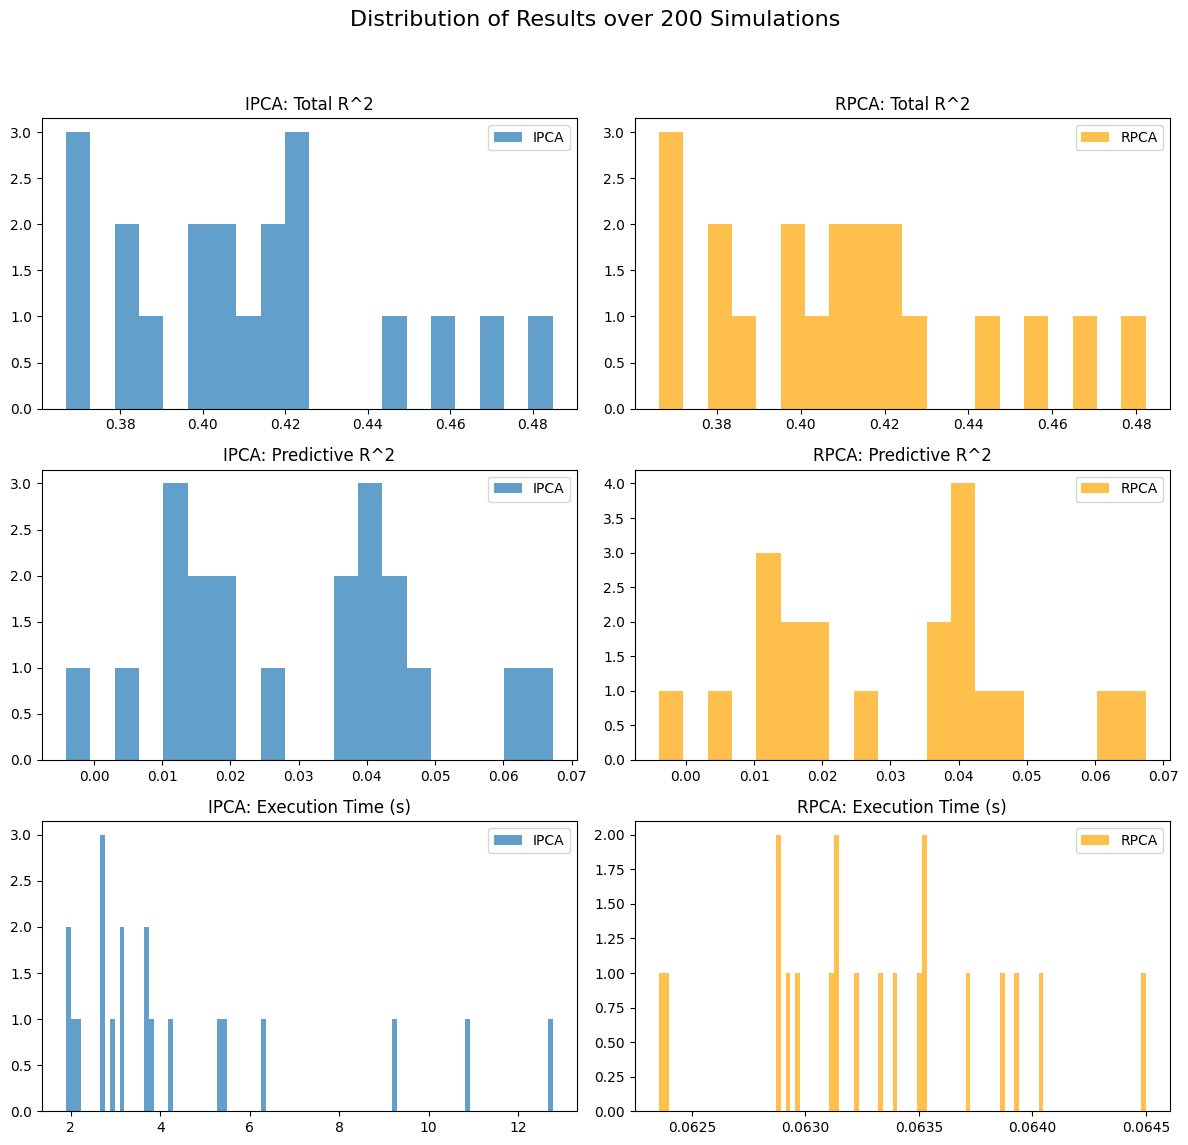

In [16]:
fig, axes = plt.subplots(3, 2, figsize=(12, 12))
fig.suptitle('Distribution of Results over 200 Simulations', fontsize=16)

axes[0, 0].hist(ipca_r2_total, bins=20, alpha=0.7, label='IPCA')
axes[0, 0].set_title('IPCA: Total R^2')
axes[0, 0].legend()

axes[0, 1].hist(rpca_r2_total, bins=20, alpha=0.7, label='RPCA', color='orange')
axes[0, 1].set_title('RPCA: Total R^2')
axes[0, 1].legend()

axes[1, 0].hist(ipca_r2_pred, bins=20, alpha=0.7, label='IPCA')
axes[1, 0].set_title('IPCA: Predictive R^2')
axes[1, 0].legend()

axes[1, 1].hist(rpca_r2_pred, bins=20, alpha=0.7, label='RPCA', color='orange')
axes[1, 1].set_title('RPCA: Predictive R^2')
axes[1, 1].legend()

axes[2, 0].hist(ipca_times, bins=100, alpha=0.7, label='IPCA')
axes[2, 0].set_title('IPCA: Execution Time (s)')
axes[2, 0].legend()

axes[2, 1].hist(rpca_times, bins=100, alpha=0.7, label='RPCA', color='orange')
axes[2, 1].set_title('RPCA: Execution Time (s)')
axes[2, 1].legend()

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()